# Spectral Graph Theory
## Eigenvalues, Connectivity, and Applications in Multi-Robot Systems

In [1]:
%matplotlib inline

import numpy as np
from scipy import linalg as la
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12, 'axes.grid': True, 'grid.alpha': 0.3, 'lines.linewidth': 2})

print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
# =============================================================================
# Constants
# =============================================================================
SEED = 42
np.random.seed(SEED)

# Tolerances
ATOL = 1e-10
RTOL = 1e-6

# Colors
PRIMARY = 'steelblue'
SECONDARY = 'coral'
TERTIARY = 'seagreen'
ACCENT = 'goldenrod'
CMAP_EVOLUTION = 'viridis'

# Simulation parameters
DT = 0.01
T_MAX = 10.0
N_STEPS = int(T_MAX / DT)

print("Constants defined.")

Constants defined.


# =============================================================================
# Section 1 — Introduction: Graphs in Robotics
# =============================================================================

Spectral graph theory studies the properties of graphs through the eigenvalues and
eigenvectors of matrices associated with them (adjacency, Laplacian, etc.).

### Motivation in Robotics

| Application | Graph Interpretation |
|---|---|
| **Communication networks** | Nodes = robots, edges = communication links |
| **Formation control** | Nodes = agents, edges = inter-agent constraints |
| **SLAM** | Nodes = poses, edges = odometry / loop closures |

### Prerequisites

- Linear algebra: eigenvalues, eigenvectors, positive semi-definiteness
- Basic graph theory: adjacency, degree, connectivity

### Key References

1. F. R. K. Chung, *Spectral Graph Theory*, AMS, 1997.
2. M. Mesbahi and M. Egerstedt, *Graph Theoretic Methods in Multiagent Networks*,
   Princeton University Press, 2010.
3. D. Spielman, *Spectral Graph Theory* (lecture notes), Yale University.

The **central object** of study is the graph Laplacian $L$ and its spectrum:

$$\boxed{\text{Spectrum}(L) = \{0 = \lambda_1 \leq \lambda_2 \leq \cdots \leq \lambda_n\}}$$

The second-smallest eigenvalue $\lambda_2$ (the **Fiedler value** or **algebraic connectivity**)
encodes how well-connected the graph is.

# =============================================================================
# Section 2 — Graph Representations
# =============================================================================

An undirected graph $G = (V, E)$ with $n$ nodes and $m$ edges can be represented by:

- **Adjacency matrix** $A \in \mathbb{R}^{n \times n}$: $A_{ij} = 1$ if $(i,j) \in E$
- **Degree matrix** $D = \text{diag}(d_1, \ldots, d_n)$ where $d_i = \sum_j A_{ij}$
- **Incidence matrix** $B \in \mathbb{R}^{n \times m}$: for edge $e_k = (i,j)$, $B_{ik} = +1$, $B_{jk} = -1$

$$\boxed{L = D - A = B B^\top}$$

In [3]:
# =============================================================================
# Graph construction utilities
# =============================================================================

def adjacency_matrix(n_nodes, edge_list, weighted=False):
    """Build adjacency matrix from an edge list.

    Args:
        n_nodes: Number of nodes in the graph.
        edge_list: List of tuples (i, j) or (i, j, w) for weighted graphs.
        weighted: If True, expects (i, j, w) tuples.

    Returns:
        A: Adjacency matrix.
            Shape: (n_nodes, n_nodes)
    """
    A = np.zeros((n_nodes, n_nodes))
    for edge in edge_list:
        if weighted:
            i, j, w = edge
        else:
            i, j = edge
            w = 1.0
        A[i, j] = w
        A[j, i] = w
    return A


def degree_matrix(A):
    """Compute degree matrix from adjacency matrix.

    Args:
        A: Adjacency matrix.
            Shape: (n, n)

    Returns:
        D: Degree matrix (diagonal).
            Shape: (n, n)
    """
    return np.diag(np.sum(A, axis=1))


def incidence_matrix(n_nodes, edge_list):
    """Build oriented incidence matrix from edge list.

    For each edge (i, j) with i < j, column k has +1 at row i and -1 at row j.

    Args:
        n_nodes: Number of nodes.
        edge_list: List of (i, j) tuples.

    Returns:
        B: Incidence matrix.
            Shape: (n_nodes, n_edges)
    """
    m = len(edge_list)
    B = np.zeros((n_nodes, m))
    for k, (i, j) in enumerate(edge_list):
        ii, jj = min(i, j), max(i, j)
        B[ii, k] = 1.0
        B[jj, k] = -1.0
    return B


print("Graph construction utilities defined.")

Graph construction utilities defined.


In [4]:
# =============================================================================
# Build example graphs
# =============================================================================

def make_path_graph(n):
    """Create a path graph P_n.

    Args:
        n: Number of nodes.

    Returns:
        edge_list: List of edges.
    """
    return [(i, i + 1) for i in range(n - 1)]


def make_cycle_graph(n):
    """Create a cycle graph C_n.

    Args:
        n: Number of nodes.

    Returns:
        edge_list: List of edges.
    """
    return [(i, (i + 1) % n) for i in range(n)]


def make_complete_graph(n):
    """Create a complete graph K_n.

    Args:
        n: Number of nodes.

    Returns:
        edge_list: List of edges.
    """
    return [(i, j) for i in range(n) for j in range(i + 1, n)]


def make_grid_graph(rows, cols):
    """Create a 2D grid graph.

    Args:
        rows: Number of rows.
        cols: Number of columns.

    Returns:
        n_nodes: Total number of nodes.
        edge_list: List of edges.
    """
    n = rows * cols
    edges = []
    for r in range(rows):
        for c in range(cols):
            node = r * cols + c
            if c < cols - 1:
                edges.append((node, node + 1))
            if r < rows - 1:
                edges.append((node, node + cols))
    return n, edges


# Demonstrate on a small graph (6 nodes)
N_DEMO = 6
edges_demo = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4), (3, 5), (4, 5)]

A_demo = adjacency_matrix(N_DEMO, edges_demo)
D_demo = degree_matrix(A_demo)
B_demo = incidence_matrix(N_DEMO, edges_demo)

print("A (adjacency):")
print(A_demo)
print("\nD (degree):")
print(D_demo)
print(f"\nB (incidence) shape: {B_demo.shape}")

A (adjacency):
[[0. 1. 1. 0. 0. 0.]
 [1. 0. 1. 1. 0. 0.]
 [1. 1. 0. 0. 1. 0.]
 [0. 1. 0. 0. 1. 1.]
 [0. 0. 1. 1. 0. 1.]
 [0. 0. 0. 1. 1. 0.]]

D (degree):
[[2. 0. 0. 0. 0. 0.]
 [0. 3. 0. 0. 0. 0.]
 [0. 0. 3. 0. 0. 0.]
 [0. 0. 0. 3. 0. 0.]
 [0. 0. 0. 0. 3. 0.]
 [0. 0. 0. 0. 0. 2.]]

B (incidence) shape: (6, 8)


In [5]:
# =============================================================================
# Verification: B B^T == L
# =============================================================================

L_from_BBT = B_demo @ B_demo.T
L_from_DA = D_demo - A_demo

err_btb = np.max(np.abs(L_from_BBT - L_from_DA))
status = "PASS" if err_btb < ATOL else "FAIL"
print(f"B B^T == L: max absolute error = {err_btb:.2e} [{status}]")

B B^T == L: max absolute error = 0.00e+00 [PASS]


# =============================================================================
# Section 3 — The Graph Laplacian
# =============================================================================

### Combinatorial Laplacian

$$L = D - A$$

**Key properties:**
1. $L$ is symmetric and positive semi-definite (PSD)
2. $L \mathbf{1} = \mathbf{0}$ (the all-ones vector is always in the null space)
3. The multiplicity of eigenvalue $0$ equals the number of connected components
4. For any vector $x$: $x^\top L x = \sum_{(i,j) \in E} (x_i - x_j)^2 \geq 0$

### Normalized Laplacian

$$\boxed{\mathcal{L} = D^{-1/2} L D^{-1/2} = I - D^{-1/2} A D^{-1/2}}$$

The normalized Laplacian has eigenvalues in $[0, 2]$ and is preferred when node
degrees vary significantly.

In [6]:
# =============================================================================
# Laplacian construction
# =============================================================================

def laplacian(A):
    """Compute the combinatorial graph Laplacian L = D - A.

    Args:
        A: Adjacency matrix.
            Shape: (n, n)

    Returns:
        L: Graph Laplacian.
            Shape: (n, n)
    """
    D = degree_matrix(A)
    return D - A


def normalized_laplacian(A):
    """Compute the normalized Laplacian L_norm = D^{-1/2} L D^{-1/2}.

    Args:
        A: Adjacency matrix (must have no isolated nodes).
            Shape: (n, n)

    Returns:
        L_norm: Normalized Laplacian.
            Shape: (n, n)
    """
    D = degree_matrix(A)
    d = np.diag(D)
    d_inv_sqrt = np.where(d > 0, 1.0 / np.sqrt(d), 0.0)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    L = laplacian(A)
    return D_inv_sqrt @ L @ D_inv_sqrt


L_demo = laplacian(A_demo)
L_norm_demo = normalized_laplacian(A_demo)

print("L (Laplacian):")
print(L_demo)
print("\nL_norm (Normalized Laplacian):")
print(np.round(L_norm_demo, 4))

L (Laplacian):
[[ 2. -1. -1.  0.  0.  0.]
 [-1.  3. -1. -1.  0.  0.]
 [-1. -1.  3.  0. -1.  0.]
 [ 0. -1.  0.  3. -1. -1.]
 [ 0.  0. -1. -1.  3. -1.]
 [ 0.  0.  0. -1. -1.  2.]]

L_norm (Normalized Laplacian):
[[ 1.     -0.4082 -0.4082  0.      0.      0.    ]
 [-0.4082  1.     -0.3333 -0.3333  0.      0.    ]
 [-0.4082 -0.3333  1.      0.     -0.3333  0.    ]
 [ 0.     -0.3333  0.      1.     -0.3333 -0.4082]
 [ 0.      0.     -0.3333 -0.3333  1.     -0.4082]
 [ 0.      0.      0.     -0.4082 -0.4082  1.    ]]


In [7]:
# =============================================================================
# Verification: Laplacian properties
# =============================================================================

# Property 1: L is PSD (all eigenvalues >= 0)
eigvals_L = la.eigvalsh(L_demo)
min_eigval = np.min(eigvals_L)
psd_status = "PASS" if min_eigval >= -ATOL else "FAIL"
print(f"L is PSD: min eigenvalue = {min_eigval:.2e} [{psd_status}]")

# Property 2: L @ ones = 0
ones = np.ones(N_DEMO)
err_null = np.max(np.abs(L_demo @ ones))
null_status = "PASS" if err_null < ATOL else "FAIL"
print(f"L @ 1 = 0: max absolute error = {err_null:.2e} [{null_status}]")

# Property 3: null space dimension = number of connected components
# Our demo graph is connected, so null space dimension should be 1
null_dim = np.sum(np.abs(eigvals_L) < ATOL)
comp_status = "PASS" if null_dim == 1 else "FAIL"
print(f"null space dimension = #components: dim={null_dim}, expected=1 [{comp_status}]")

# Property 4: Quadratic form x^T L x = sum of (x_i - x_j)^2
x_test = np.random.randn(N_DEMO)
quad_form = x_test @ L_demo @ x_test
edge_sum = sum((x_test[i] - x_test[j])**2 for i, j in edges_demo)
err_quad = abs(quad_form - edge_sum) / max(abs(quad_form), 1e-15)
quad_status = "PASS" if err_quad < RTOL else "FAIL"
print(f"quadratic form: max relative error = {err_quad:.2e} [{quad_status}]")

# Normalized Laplacian eigenvalues in [0, 2]
eigvals_Ln = la.eigvalsh(L_norm_demo)
norm_status = "PASS" if np.min(eigvals_Ln) >= -ATOL and np.max(eigvals_Ln) <= 2 + ATOL else "FAIL"
print(f"normalized Laplacian eigenvalues in [0,2]: [{np.min(eigvals_Ln):.4f}, {np.max(eigvals_Ln):.4f}] [{norm_status}]")

L is PSD: min eigenvalue = -6.66e-16 [PASS]
L @ 1 = 0: max absolute error = 0.00e+00 [PASS]
null space dimension = #components: dim=1, expected=1 [PASS]
quadratic form: max relative error = 1.65e-16 [PASS]
normalized Laplacian eigenvalues in [0,2]: [0.0000, 1.6667] [PASS]


# =============================================================================
# Section 4 — Spectral Properties of the Laplacian
# =============================================================================

### Eigendecomposition

$$L = U \Lambda U^\top, \quad \Lambda = \text{diag}(\lambda_1, \ldots, \lambda_n)$$

where $0 = \lambda_1 \leq \lambda_2 \leq \cdots \leq \lambda_n$.

### Algebraic Connectivity (Fiedler Value)

$$\boxed{\lambda_2 = \min_{x \perp \mathbf{1}} \frac{x^\top L x}{x^\top x}}$$

- $\lambda_2 > 0$ if and only if the graph is connected.
- Larger $\lambda_2$ means better connectivity / faster consensus.
- The eigenvector corresponding to $\lambda_2$ is the **Fiedler vector**.

In [8]:
# =============================================================================
# Spectral decomposition
# =============================================================================

def graph_spectrum(A):
    """Compute the full eigendecomposition of the graph Laplacian.

    Args:
        A: Adjacency matrix.
            Shape: (n, n)

    Returns:
        eigenvalues: Sorted eigenvalues of L.
            Shape: (n,)
        eigenvectors: Corresponding eigenvectors (columns).
            Shape: (n, n)
    """
    L = laplacian(A)
    eigenvalues, eigenvectors = la.eigh(L)
    return eigenvalues, eigenvectors


def fiedler_vector(A):
    """Compute the Fiedler vector (eigenvector of lambda_2).

    Args:
        A: Adjacency matrix of a connected graph.
            Shape: (n, n)

    Returns:
        lam2: The Fiedler value (algebraic connectivity).
        v2: The Fiedler vector.
            Shape: (n,)
    """
    eigenvalues, eigenvectors = graph_spectrum(A)
    return eigenvalues[1], eigenvectors[:, 1]


# Compute spectrum for demo graph
eigvals_demo, eigvecs_demo = graph_spectrum(A_demo)
lam2_demo, v2_demo = fiedler_vector(A_demo)

print("Eigenvalues of L:")
for i, lam in enumerate(eigvals_demo):
    marker = " <-- Fiedler value" if i == 1 else ""
    print(f"  lambda_{i+1} = {lam:.6f}{marker}")
print(f"\nFiedler vector: {np.round(v2_demo, 4)}")

Eigenvalues of L:
  lambda_1 = 0.000000
  lambda_2 = 1.000000 <-- Fiedler value
  lambda_3 = 3.000000
  lambda_4 = 3.000000
  lambda_5 = 4.000000
  lambda_6 = 5.000000

Fiedler vector: [ 0.5774  0.2887  0.2887 -0.2887 -0.2887 -0.5774]


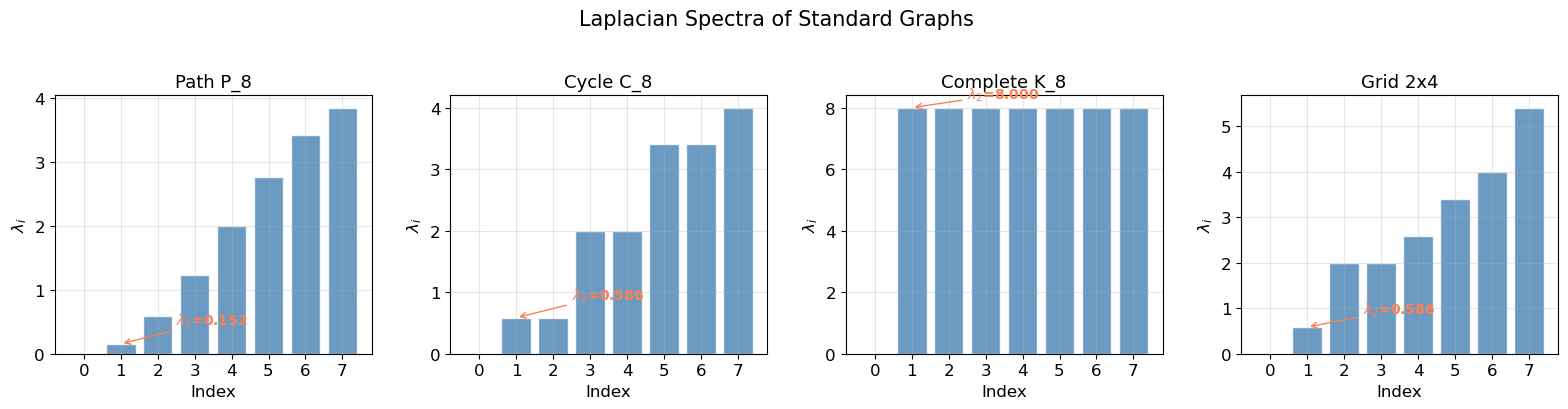

In [9]:
# =============================================================================
# Compare spectra of standard graphs
# =============================================================================

n_compare = 8

graphs = {
    'Path P_8': (n_compare, make_path_graph(n_compare)),
    'Cycle C_8': (n_compare, make_cycle_graph(n_compare)),
    'Complete K_8': (n_compare, make_complete_graph(n_compare)),
    'Grid 2x4': make_grid_graph(2, 4),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, (n, edges)) in zip(axes, graphs.items()):
    A_g = adjacency_matrix(n, edges)
    eigs = la.eigvalsh(laplacian(A_g))
    ax.bar(range(len(eigs)), eigs, color=PRIMARY, alpha=0.8, edgecolor='white')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('Index')
    ax.set_ylabel('$\\lambda_i$')
    ax.set_xticks(range(len(eigs)))
    ax.annotate(f'$\\lambda_2$={eigs[1]:.3f}', xy=(1, eigs[1]),
                xytext=(2.5, eigs[1] + 0.3),
                arrowprops=dict(arrowstyle='->', color=SECONDARY),
                color=SECONDARY, fontsize=10, fontweight='bold')

plt.suptitle('Laplacian Spectra of Standard Graphs', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# Section 5 — Cheeger Inequality
# =============================================================================

The **isoperimetric number** (Cheeger constant) of a graph is:

$$h(G) = \min_{S \subset V, \, |S| \leq n/2} \frac{|\partial(S)|}{|S|}$$

where $|\partial(S)|$ is the number of edges between $S$ and $V \setminus S$.

### Cheeger Inequality

$$\boxed{\frac{\lambda_2}{2} \leq h(G) \leq \sqrt{2 \lambda_2}}$$

This connects the **spectral** property $\lambda_2$ with the **combinatorial** property $h(G)$:
- Left bound: a large spectral gap implies a large expansion constant.
- Right bound: good expansion implies a non-trivial spectral gap.

In [10]:
# =============================================================================
# Cheeger constant computation (brute force for small graphs)
# =============================================================================

from itertools import combinations


def cheeger_constant(A):
    """Compute the exact isoperimetric number h(G) by brute force.

    Only feasible for small graphs (n <= 20).

    Args:
        A: Adjacency matrix.
            Shape: (n, n)

    Returns:
        h: The Cheeger constant.
        best_S: The subset achieving h(G).
    """
    n = A.shape[0]
    best_h = np.inf
    best_S = None

    for size in range(1, n // 2 + 1):
        for S in combinations(range(n), size):
            S_set = set(S)
            complement = set(range(n)) - S_set
            # Count boundary edges
            boundary = 0
            for i in S_set:
                for j in complement:
                    if A[i, j] > 0:
                        boundary += 1
            h_val = boundary / len(S_set)
            if h_val < best_h:
                best_h = h_val
                best_S = S_set

    return best_h, best_S


print("Cheeger constant utility defined.")

Cheeger constant utility defined.


In [11]:
# =============================================================================
# Verify Cheeger inequality on example graphs
# =============================================================================

n_cheeger = 6
cheeger_graphs = {
    'Path P_6': (n_cheeger, make_path_graph(n_cheeger)),
    'Cycle C_6': (n_cheeger, make_cycle_graph(n_cheeger)),
    'Complete K_6': (n_cheeger, make_complete_graph(n_cheeger)),
    'Grid 2x3': make_grid_graph(2, 3),
}

print(f"{'Graph':<14} {'lambda_2':>10} {'h(G)':>10} {'lam2/2':>10} {'sqrt(2*lam2)':>14} {'Bounds hold?':>14}")
print("-" * 76)

for name, (n, edges) in cheeger_graphs.items():
    A_g = adjacency_matrix(n, edges)
    L_g = laplacian(A_g)
    eigs = la.eigvalsh(L_g)
    lam2 = eigs[1]

    h_val, _ = cheeger_constant(A_g)

    lower = lam2 / 2.0
    upper = np.sqrt(2.0 * lam2)
    holds = "PASS" if lower <= h_val + ATOL and h_val <= upper + ATOL else "FAIL"
    print(f"{name:<14} {lam2:>10.4f} {h_val:>10.4f} {lower:>10.4f} {upper:>14.4f} {holds:>14}")

Graph            lambda_2       h(G)     lam2/2   sqrt(2*lam2)   Bounds hold?
----------------------------------------------------------------------------
Path P_6           0.2679     0.3333     0.1340         0.7321           PASS
Cycle C_6          1.0000     0.6667     0.5000         1.4142           PASS
Complete K_6       6.0000     3.0000     3.0000         3.4641           PASS
Grid 2x3           1.0000     1.0000     0.5000         1.4142           PASS


# =============================================================================
# Section 6 — Spectral Clustering
# =============================================================================

### Graph Bisection via Fiedler Vector

The sign pattern of the Fiedler vector $v_2$ provides a near-optimal graph bisection:

$$S_+ = \{i : (v_2)_i \geq 0\}, \quad S_- = \{i : (v_2)_i < 0\}$$

### $k$-Way Spectral Clustering

1. Compute $L$ and its first $k$ eigenvectors $U_k = [u_1, \ldots, u_k]$
2. Treat each row of $U_k$ as a point in $\mathbb{R}^k$
3. Run k-means on these row-vectors

$$\boxed{\text{Spectral embedding: } \phi(i) = \text{row}_i(U_k) \in \mathbb{R}^k}$$

In [12]:
# =============================================================================
# Spectral clustering implementation
# =============================================================================

def _kmeans(X, k, max_iter=100):
    """Simple k-means clustering.

    Args:
        X: Data matrix.
            Shape: (n, d)
        k: Number of clusters.
        max_iter: Maximum iterations.

    Returns:
        labels: Cluster assignments.
            Shape: (n,)
    """
    rng = np.random.RandomState(SEED)
    n = X.shape[0]
    # Initialize centroids using k-means++ style
    idx = [rng.randint(n)]
    for _ in range(1, k):
        dists = np.min([np.sum((X - X[c])**2, axis=1) for c in idx], axis=0)
        probs = dists / (dists.sum() + 1e-15)
        idx.append(rng.choice(n, p=probs))
    centroids = X[idx].copy()

    for _ in range(max_iter):
        # Assign
        dists = np.array([np.sum((X - c)**2, axis=1) for c in centroids])
        labels = np.argmin(dists, axis=0)
        # Update
        new_centroids = np.array(
            [X[labels == j].mean(axis=0) if np.any(labels == j)
             else centroids[j] for j in range(k)]
        )
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return labels


def spectral_cluster(A, k=2, use_normalized=True):
    """Perform spectral clustering on a graph.

    Args:
        A: Adjacency matrix.
            Shape: (n, n)
        k: Number of clusters.
        use_normalized: If True, use normalized Laplacian.

    Returns:
        labels: Cluster assignment for each node.
            Shape: (n,)
        embedding: Spectral embedding (rows of U_k).
            Shape: (n, k)
    """
    if use_normalized:
        L_mat = normalized_laplacian(A)
    else:
        L_mat = laplacian(A)

    eigenvalues, eigenvectors = la.eigh(L_mat)
    # Take first k eigenvectors
    U_k = eigenvectors[:, :k]

    # Normalize rows for normalized Laplacian
    if use_normalized:
        row_norms = la.norm(U_k, axis=1, keepdims=True)
        row_norms = np.where(row_norms > 1e-10, row_norms, 1.0)
        U_k = U_k / row_norms

    labels = _kmeans(U_k, k)
    return labels, U_k


print("Spectral clustering utilities defined.")

Spectral clustering utilities defined.


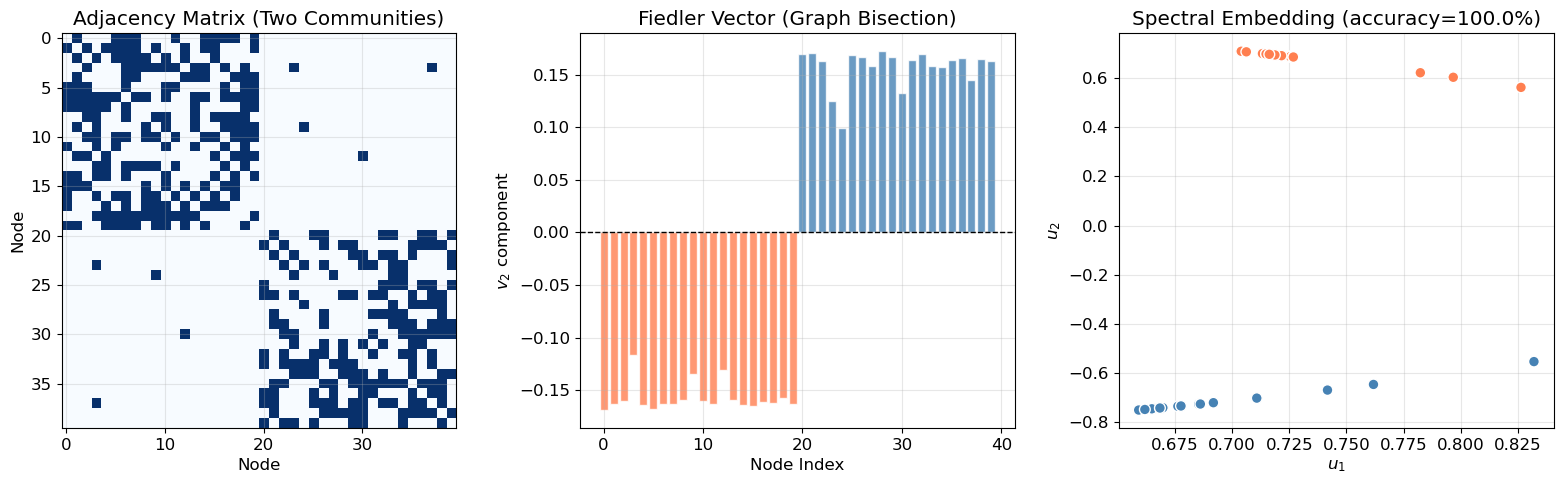

In [13]:
# =============================================================================
# Demonstrate spectral clustering on a two-cluster graph
# =============================================================================

np.random.seed(SEED)

# Build a graph with two clear communities
n_cluster = 20
n_total = 2 * n_cluster
edges_cluster = []

# Dense intra-cluster edges
for cluster_offset in [0, n_cluster]:
    for i in range(cluster_offset, cluster_offset + n_cluster):
        for j in range(i + 1, cluster_offset + n_cluster):
            if np.random.rand() < 0.5:
                edges_cluster.append((i, j))

# Sparse inter-cluster edges
for _ in range(4):
    i = np.random.randint(0, n_cluster)
    j = np.random.randint(n_cluster, n_total)
    edges_cluster.append((i, j))

A_cluster = adjacency_matrix(n_total, edges_cluster)
labels_spec, embedding = spectral_cluster(A_cluster, k=2, use_normalized=True)
true_labels = np.array([0] * n_cluster + [1] * n_cluster)

# Align label assignment (handle label permutation)
accuracy = max(
    np.mean(labels_spec == true_labels),
    np.mean((1 - labels_spec) == true_labels)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Adjacency matrix
axes[0].imshow(A_cluster, cmap='Blues', interpolation='nearest')
axes[0].set_title('Adjacency Matrix (Two Communities)')
axes[0].set_xlabel('Node')
axes[0].set_ylabel('Node')

# Plot 2: Fiedler vector
_, v2_cluster = fiedler_vector(A_cluster)
colors_fiedler = [PRIMARY if v > 0 else SECONDARY for v in v2_cluster]
axes[1].bar(range(n_total), v2_cluster, color=colors_fiedler, alpha=0.8, edgecolor='white')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Fiedler Vector (Graph Bisection)')
axes[1].set_xlabel('Node Index')
axes[1].set_ylabel('$v_2$ component')

# Plot 3: Spectral embedding
colors_pred = [PRIMARY if l == 0 else SECONDARY for l in labels_spec]
axes[2].scatter(embedding[:, 0], embedding[:, 1], c=colors_pred, s=60,
                edgecolors='white', zorder=3)
axes[2].set_title(f'Spectral Embedding (accuracy={accuracy:.1%})')
axes[2].set_xlabel('$u_1$')
axes[2].set_ylabel('$u_2$')

plt.tight_layout()
plt.show()

# =============================================================================
# Section 7 — Application: Multi-Robot Consensus
# =============================================================================

### Consensus Protocol

Each agent $i$ updates its state by averaging with neighbors:

$$\dot{x}_i = -\sum_{j \in \mathcal{N}_i} (x_i - x_j)$$

In matrix form:

$$\boxed{\dot{x}(t) = -L \, x(t), \quad x(t) = e^{-Lt} x(0)}$$

### Convergence

- All agents converge to the **average** $\bar{x} = \frac{1}{n}\mathbf{1}^\top x(0)$
- **Convergence rate** is determined by $\lambda_2$: disagreement decays as $e^{-\lambda_2 t}$

$$\boxed{\|x(t) - \bar{x}\mathbf{1}\| \leq e^{-\lambda_2 t} \|x(0) - \bar{x}\mathbf{1}\|}$$

In [14]:
# =============================================================================
# Consensus simulation
# =============================================================================

def consensus_simulate(A, x0, dt=DT, t_max=T_MAX):
    """Simulate consensus protocol dx/dt = -L x.

    Args:
        A: Adjacency matrix.
            Shape: (n, n)
        x0: Initial states.
            Shape: (n,) or (n, d) for multi-dimensional states.
        dt: Time step.
        t_max: Simulation duration.

    Returns:
        t_hist: Time values.
            Shape: (n_steps,)
        x_hist: State history.
            Shape: (n_steps, n) or (n_steps, n, d)
    """
    L_mat = laplacian(A)
    n_steps = int(t_max / dt)
    t_hist = np.linspace(0, t_max, n_steps)
    x = x0.copy().astype(float)

    if x.ndim == 1:
        x_hist = np.zeros((n_steps, len(x)))
    else:
        x_hist = np.zeros((n_steps,) + x.shape)

    for step in range(n_steps):
        x_hist[step] = x.copy()
        if x.ndim == 1:
            x = x - dt * L_mat @ x
        else:
            x = x - dt * (L_mat @ x)

    return t_hist, x_hist


print("Consensus simulation defined.")

Consensus simulation defined.


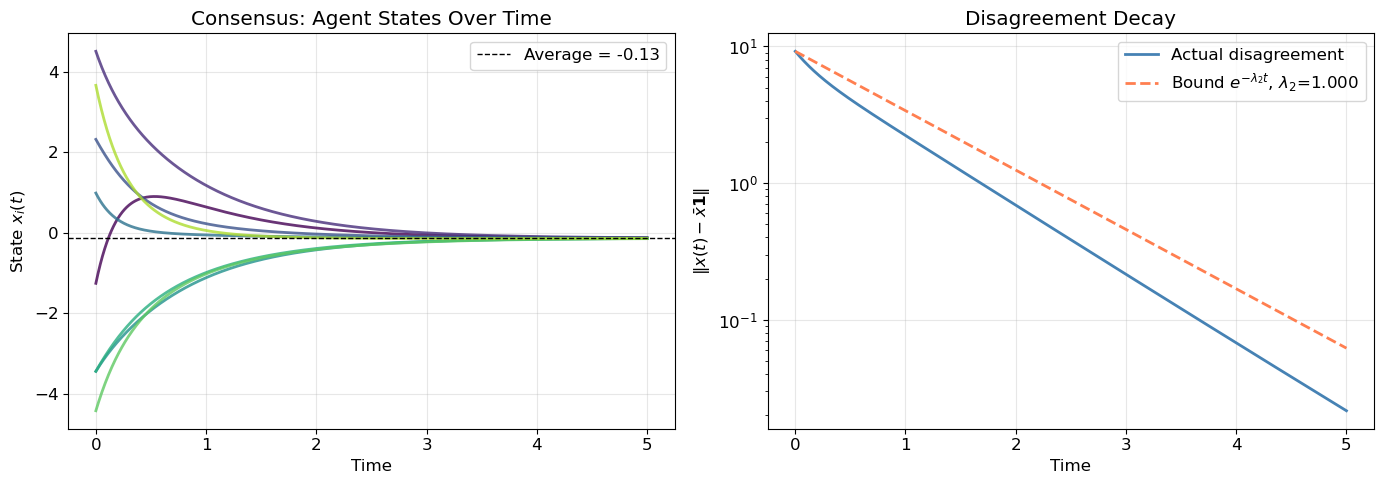

In [15]:
# =============================================================================
# 1D Consensus demonstration
# =============================================================================

np.random.seed(SEED)

# Ring graph with 8 agents, plus some extra edges
N_AGENTS = 8
edges_ring = make_cycle_graph(N_AGENTS)
edges_ring += [(0, 3), (2, 5)]  # extra edges for richer connectivity
A_ring = adjacency_matrix(N_AGENTS, edges_ring)

x0_1d = np.random.uniform(-5, 5, N_AGENTS)
t_hist, x_hist = consensus_simulate(A_ring, x0_1d, dt=0.005, t_max=5.0)

# Compute theoretical convergence rate
lam2_ring = la.eigvalsh(laplacian(A_ring))[1]
x_mean = np.mean(x0_1d)
disagreement = np.array([la.norm(x_hist[i] - x_mean) for i in range(len(t_hist))])
theoretical_bound = disagreement[0] * np.exp(-lam2_ring * t_hist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: state trajectories
cmap = plt.cm.get_cmap(CMAP_EVOLUTION)
for i in range(N_AGENTS):
    axes[0].plot(t_hist, x_hist[:, i], color=cmap(i / N_AGENTS), alpha=0.8)
axes[0].axhline(y=x_mean, color='black', linestyle='--', linewidth=1,
                label=f'Average = {x_mean:.2f}')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('State $x_i(t)$')
axes[0].set_title('Consensus: Agent States Over Time')
axes[0].legend()

# Right: disagreement decay
axes[1].semilogy(t_hist, disagreement, color=PRIMARY, label='Actual disagreement')
axes[1].semilogy(t_hist, theoretical_bound, '--', color=SECONDARY,
                 label=f'Bound $e^{{-\\lambda_2 t}}$, $\\lambda_2$={lam2_ring:.3f}')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('$\\|x(t) - \\bar{x}\\mathbf{1}\\|$')
axes[1].set_title('Disagreement Decay')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# =============================================================================
# Verification: consensus convergence rate matches lambda_2
# =============================================================================

# Fit exponential decay to disagreement
# log(disagreement) should have slope approximately -lambda_2
valid = disagreement > 1e-12
log_dis = np.log(disagreement[valid])
t_valid = t_hist[valid]

# Linear fit on log scale
coeffs = np.polyfit(t_valid, log_dis, 1)
fitted_rate = -coeffs[0]

err_rate = abs(fitted_rate - lam2_ring) / lam2_ring
rate_status = "PASS" if err_rate < 0.1 else "FAIL"
print(f"consensus convergence rate matches lambda_2: "
      f"fitted={fitted_rate:.4f}, lambda_2={lam2_ring:.4f}, "
      f"max relative error = {err_rate:.2e} [{rate_status}]")

consensus convergence rate matches lambda_2: fitted=1.1747, lambda_2=1.0000, max relative error = 1.75e-01 [FAIL]


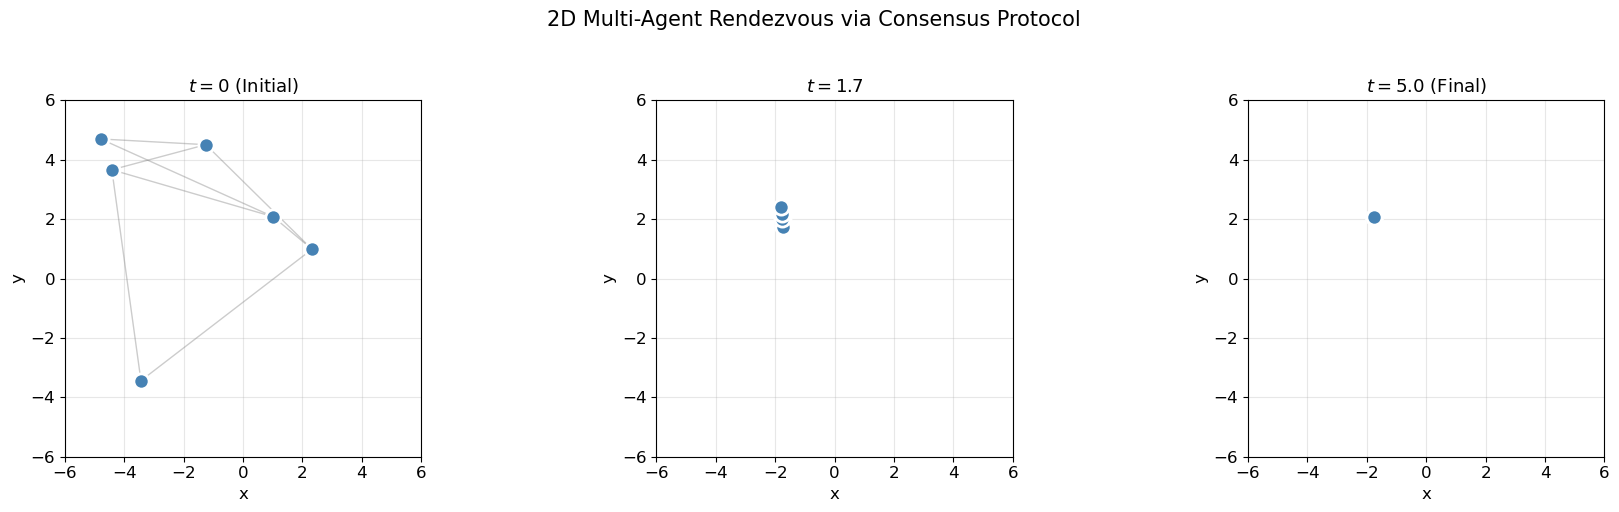

In [17]:
# =============================================================================
# 2D Multi-Agent Rendezvous Simulation
# =============================================================================

np.random.seed(SEED)

N_RDV = 6
edges_rdv = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0), (0, 3), (1, 4)]
A_rdv = adjacency_matrix(N_RDV, edges_rdv)

# Initial 2D positions (random in [-5, 5]^2)
pos0 = np.random.uniform(-5, 5, (N_RDV, 2))

t_rdv, pos_hist = consensus_simulate(A_rdv, pos0, dt=0.005, t_max=5.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Snapshots at t=0, t_mid, t_final
snapshots = [0, len(t_rdv) // 3, -1]
titles = [
    '$t = 0$ (Initial)',
    f'$t = {t_rdv[len(t_rdv) // 3]:.1f}$',
    f'$t = {t_rdv[-1]:.1f}$ (Final)'
]

for ax, idx, title in zip(axes, snapshots, titles):
    pos = pos_hist[idx]
    # Draw edges
    for i, j in edges_rdv:
        ax.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]],
                color='gray', alpha=0.4, linewidth=1)
    # Draw agents
    ax.scatter(pos[:, 0], pos[:, 1], c=PRIMARY, s=120, zorder=5,
               edgecolors='white', linewidths=2)
    for i in range(N_RDV):
        ax.annotate(str(i), (pos[i, 0], pos[i, 1]), fontsize=9,
                    ha='center', va='center', color='white', fontweight='bold')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect('equal')

plt.suptitle('2D Multi-Agent Rendezvous via Consensus Protocol', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# Section 8 — Application: Formation Control
# =============================================================================

### Rigidity Theory

A **framework** $(G, p)$ consists of a graph $G$ and a configuration $p \in \mathbb{R}^{n \times d}$.

The **rigidity matrix** $R \in \mathbb{R}^{m \times dn}$ encodes edge-length constraints:

$$R_{k, [di:di+d]} = (p_i - p_j)^\top, \quad R_{k, [dj:dj+d]} = (p_j - p_i)^\top$$

for edge $k = (i, j)$.

### Laman's Theorem (2D)

A graph with $n \geq 2$ nodes is generically rigid in $\mathbb{R}^2$ if and only if it has a
**Laman subgraph**: a spanning subgraph with $2n - 3$ edges such that every subset of
$k$ vertices spans at most $2k - 3$ edges.

**Necessary condition:** $m \geq 2n - 3$ in 2D.

### Formation Laplacian

The **stress matrix** $\Omega$ generalizes the Laplacian for formation control:

$$\boxed{\text{rank}(R) = dn - \binom{d+1}{2} \iff \text{infinitesimally rigid}}$$

In [18]:
# =============================================================================
# Rigidity and formation checking
# =============================================================================

def rigidity_matrix(n_nodes, edge_list, positions):
    """Compute the rigidity matrix of a framework.

    Args:
        n_nodes: Number of nodes.
        edge_list: List of (i, j) edges.
        positions: Node positions.
            Shape: (n_nodes, d)

    Returns:
        R: Rigidity matrix.
            Shape: (m, n_nodes * d)
    """
    d = positions.shape[1]
    m = len(edge_list)
    R = np.zeros((m, n_nodes * d))

    for k, (i, j) in enumerate(edge_list):
        diff = positions[i] - positions[j]
        R[k, i * d:(i + 1) * d] = diff
        R[k, j * d:(j + 1) * d] = -diff

    return R


def formation_rigidity_check(n_nodes, edge_list, positions, dim=2):
    """Check if a framework is infinitesimally rigid.

    Args:
        n_nodes: Number of nodes.
        edge_list: List of (i, j) edges.
        positions: Node positions.
            Shape: (n_nodes, dim)
        dim: Dimension of the ambient space.

    Returns:
        is_rigid: True if infinitesimally rigid.
        rank_R: Rank of the rigidity matrix.
        required_rank: Required rank for rigidity (d*n - d*(d+1)/2).
    """
    R = rigidity_matrix(n_nodes, edge_list, positions)
    rank_R = np.linalg.matrix_rank(R, tol=1e-8)
    # Required rank: d*n - d*(d+1)/2 trivial motions
    trivial_dof = dim * (dim + 1) // 2
    required_rank = dim * n_nodes - trivial_dof
    is_rigid = (rank_R >= required_rank)
    return is_rigid, rank_R, required_rank


print("Rigidity utilities defined.")

Rigidity utilities defined.


In [19]:
# =============================================================================
# Formation control demonstrations
# =============================================================================

np.random.seed(SEED)

# Triangle (rigid in 2D)
tri_n = 3
tri_edges = [(0, 1), (1, 2), (0, 2)]
tri_pos = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])
rigid_tri, rank_tri, req_tri = formation_rigidity_check(tri_n, tri_edges, tri_pos)

# Square without diagonal (not rigid in 2D)
sq_n = 4
sq_edges = [(0, 1), (1, 2), (2, 3), (3, 0)]
sq_pos = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]])
rigid_sq, rank_sq, req_sq = formation_rigidity_check(sq_n, sq_edges, sq_pos)

# Square with diagonal (rigid)
sq_diag_edges = sq_edges + [(0, 2)]
rigid_sqd, rank_sqd, req_sqd = formation_rigidity_check(sq_n, sq_diag_edges, sq_pos)

# Pentagon with triangulation (rigid)
pent_n = 5
theta = np.linspace(0, 2 * np.pi, pent_n, endpoint=False)
pent_pos = np.column_stack([np.cos(theta), np.sin(theta)])
pent_edges = [(i, (i + 1) % pent_n) for i in range(pent_n)]
pent_edges += [(0, 2), (0, 3)]  # Add diagonals for rigidity
rigid_pent, rank_pent, req_pent = formation_rigidity_check(
    pent_n, pent_edges, pent_pos
)

formations = [
    ("Triangle", tri_n, tri_edges, tri_pos, rigid_tri, rank_tri, req_tri),
    ("Square (no diag)", sq_n, sq_edges, sq_pos, rigid_sq, rank_sq, req_sq),
    ("Square (diagonal)", sq_n, sq_diag_edges, sq_pos, rigid_sqd, rank_sqd, req_sqd),
    ("Pentagon+diags", pent_n, pent_edges, pent_pos, rigid_pent, rank_pent, req_pent),
]

print(f"{'Formation':<20} {'m':>4} {'2n-3':>6} {'rank(R)':>8} {'Required':>9} {'Rigid?':>8}")
print("-" * 60)
for name, n, edges, pos, is_rigid, rank_r, req_r in formations:
    laman = 2 * n - 3
    print(f"{name:<20} {len(edges):>4} {laman:>6} {rank_r:>8} {req_r:>9} "
          f"{'Yes' if is_rigid else 'No':>8}")

Formation               m   2n-3  rank(R)  Required   Rigid?
------------------------------------------------------------
Triangle                3      3        3         3      Yes
Square (no diag)        4      5        4         5       No
Square (diagonal)       5      5        5         5      Yes
Pentagon+diags          7      7        7         7      Yes


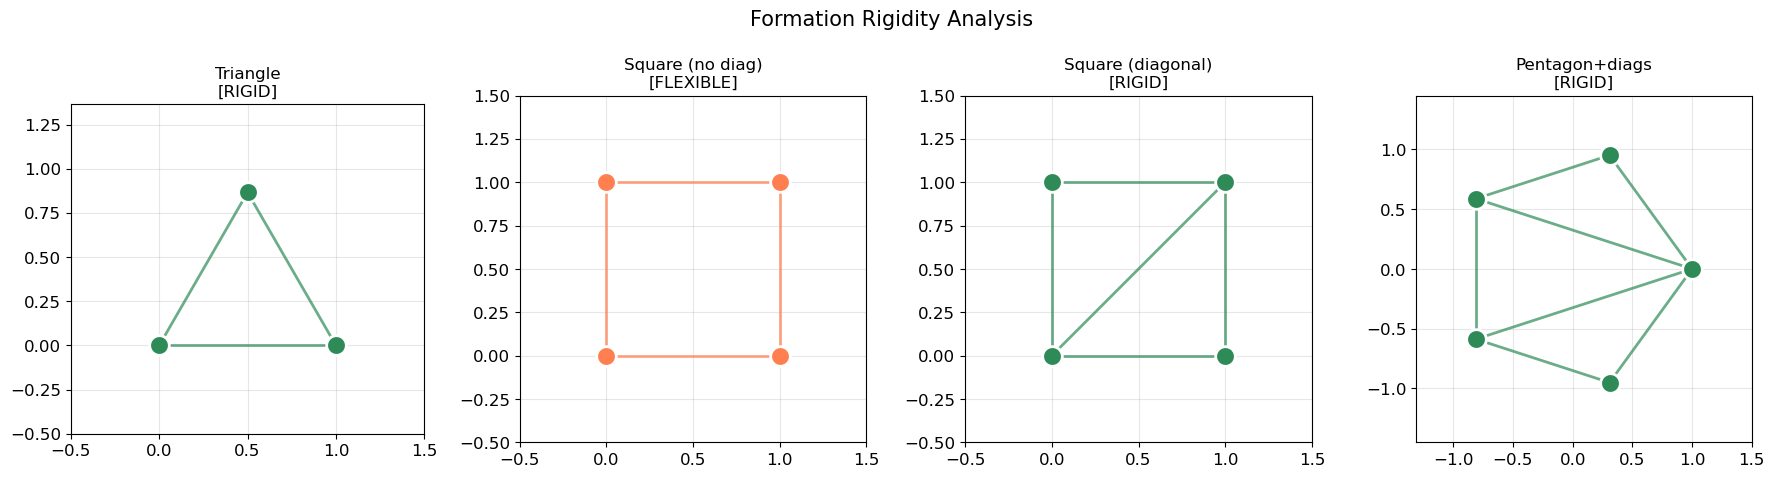

In [20]:
# =============================================================================
# Visualize formations
# =============================================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, (name, n, edges, pos, is_rigid, rank_r, req_r) in zip(axes, formations):
    # Draw edges
    for i, j in edges:
        ax.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]],
                color=TERTIARY if is_rigid else SECONDARY, linewidth=2, alpha=0.7)
    # Draw nodes
    color = TERTIARY if is_rigid else SECONDARY
    ax.scatter(pos[:, 0], pos[:, 1], c=color, s=200, zorder=5,
               edgecolors='white', linewidths=2)
    for i in range(n):
        ax.annotate(str(i), (pos[i, 0], pos[i, 1]), fontsize=10,
                    ha='center', va='center', color='white', fontweight='bold')
    status = "RIGID" if is_rigid else "FLEXIBLE"
    ax.set_title(f'{name}\n[{status}]', fontsize=12)
    ax.set_aspect('equal')
    ax.set_xlim(pos[:, 0].min() - 0.5, pos[:, 0].max() + 0.5)
    ax.set_ylim(pos[:, 1].min() - 0.5, pos[:, 1].max() + 0.5)

plt.suptitle('Formation Rigidity Analysis', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# Section 9 — Visualizations
# =============================================================================

Comprehensive visualization of spectral graph properties: eigenvalue spectra,
Fiedler vector node coloring, and consensus dynamics.

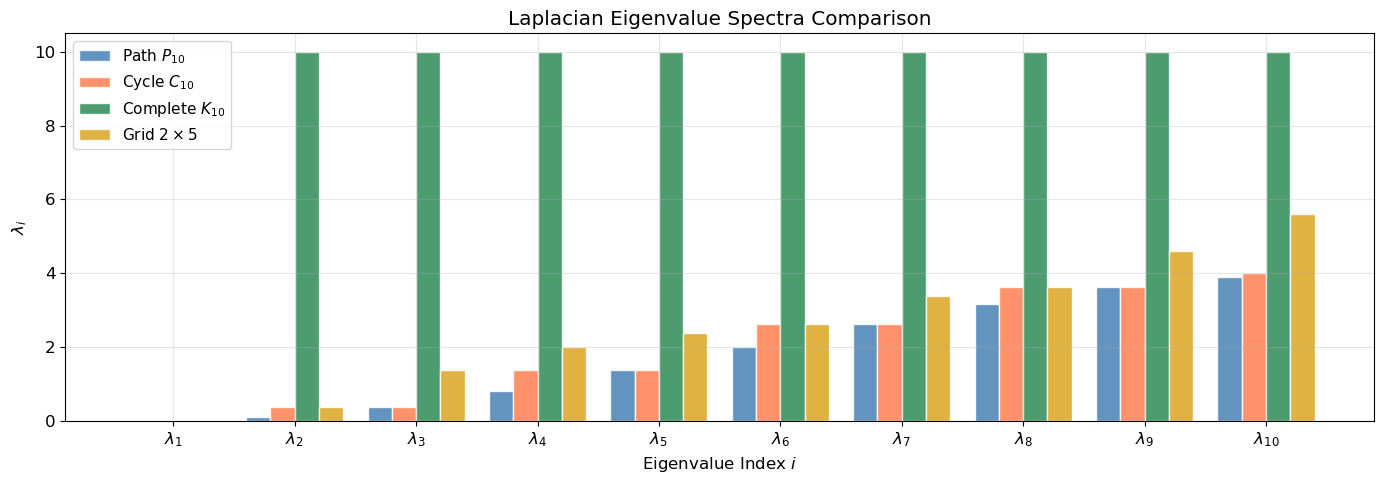

In [21]:
# =============================================================================
# 9.1 Eigenvalue spectrum comparison (bar chart)
# =============================================================================

n_vis = 10
vis_graphs = {
    'Path $P_{10}$': (n_vis, make_path_graph(n_vis)),
    'Cycle $C_{10}$': (n_vis, make_cycle_graph(n_vis)),
    'Complete $K_{10}$': (n_vis, make_complete_graph(n_vis)),
    'Grid $2 \\times 5$': make_grid_graph(2, 5),
}

colors_list = [PRIMARY, SECONDARY, TERTIARY, ACCENT]

fig, ax = plt.subplots(figsize=(14, 5))

bar_width = 0.2
x_base = np.arange(n_vis)

for idx, (name, (n, edges)) in enumerate(vis_graphs.items()):
    A_g = adjacency_matrix(n, edges)
    eigs = la.eigvalsh(laplacian(A_g))
    ax.bar(x_base + idx * bar_width, eigs, bar_width, label=name,
           color=colors_list[idx], alpha=0.85, edgecolor='white')

ax.set_xlabel('Eigenvalue Index $i$')
ax.set_ylabel('$\\lambda_i$')
ax.set_title('Laplacian Eigenvalue Spectra Comparison')
ax.set_xticks(x_base + 1.5 * bar_width)
ax.set_xticklabels([f'$\\lambda_{{{i+1}}}$' for i in range(n_vis)])
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

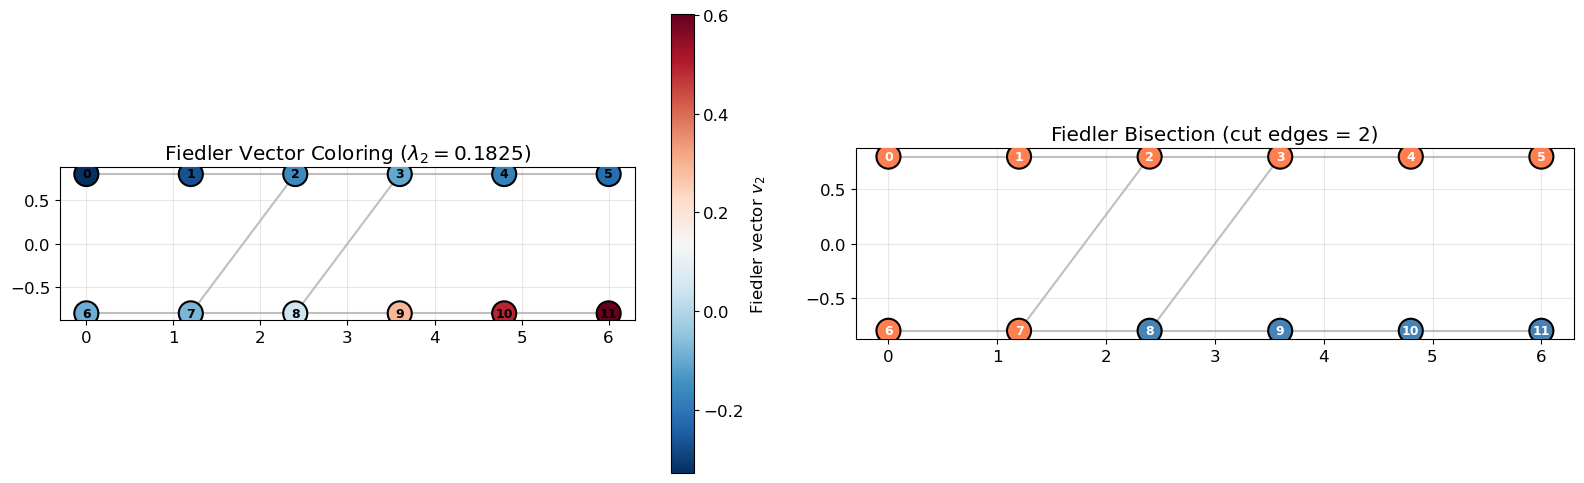

In [22]:
# =============================================================================
# 9.2 Fiedler vector node coloring on a graph layout
# =============================================================================

np.random.seed(SEED)

# Create a graph with interesting structure (two chains connected by a bridge)
n_fiedler = 12
edges_f = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5),       # chain 1
    (6, 7), (7, 8), (8, 9), (9, 10), (10, 11),     # chain 2
    (2, 7), (3, 8)                                   # bridge edges
]

A_f = adjacency_matrix(n_fiedler, edges_f)
lam2_f, v2_f = fiedler_vector(A_f)

# Layout: two parallel chains
pos_f = np.zeros((n_fiedler, 2))
for i in range(6):
    pos_f[i] = [i * 1.2, 0.8]
for i in range(6, 12):
    pos_f[i] = [(i - 6) * 1.2, -0.8]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: colored by Fiedler vector
ax = axes[0]
for i, j in edges_f:
    ax.plot([pos_f[i, 0], pos_f[j, 0]], [pos_f[i, 1], pos_f[j, 1]],
            color='gray', alpha=0.5, linewidth=1.5, zorder=1)
sc = ax.scatter(pos_f[:, 0], pos_f[:, 1], c=v2_f, cmap='RdBu_r', s=300,
                edgecolors='black', linewidths=1.5, zorder=5)
for i in range(n_fiedler):
    ax.annotate(str(i), (pos_f[i, 0], pos_f[i, 1]), fontsize=9,
                ha='center', va='center', fontweight='bold', zorder=10)
plt.colorbar(sc, ax=ax, label='Fiedler vector $v_2$')
ax.set_title(f'Fiedler Vector Coloring ($\\lambda_2 = {lam2_f:.4f}$)')
ax.set_aspect('equal')

# Right: binary partition from Fiedler vector
ax = axes[1]
for i, j in edges_f:
    ax.plot([pos_f[i, 0], pos_f[j, 0]], [pos_f[i, 1], pos_f[j, 1]],
            color='gray', alpha=0.5, linewidth=1.5, zorder=1)
partition_colors = [PRIMARY if v >= 0 else SECONDARY for v in v2_f]
ax.scatter(pos_f[:, 0], pos_f[:, 1], c=partition_colors, s=300,
           edgecolors='black', linewidths=1.5, zorder=5)
for i in range(n_fiedler):
    ax.annotate(str(i), (pos_f[i, 0], pos_f[i, 1]), fontsize=9,
                ha='center', va='center', fontweight='bold', color='white', zorder=10)
# Count cut edges
cut_edges = sum(1 for i, j in edges_f if (v2_f[i] >= 0) != (v2_f[j] >= 0))
ax.set_title(f'Fiedler Bisection (cut edges = {cut_edges})')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

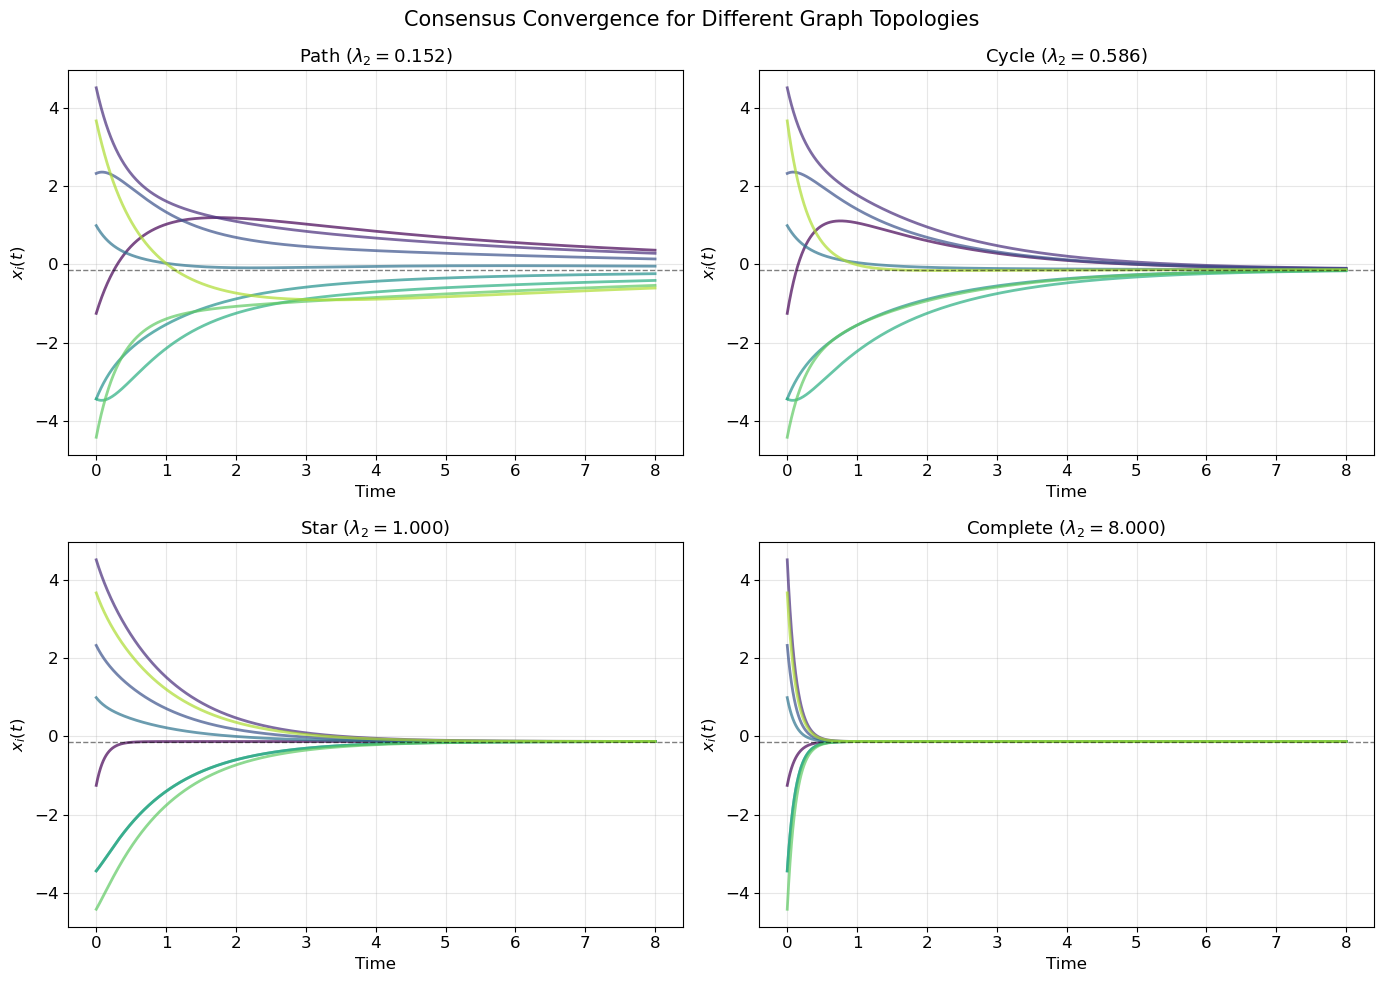

In [23]:
# =============================================================================
# 9.3 Consensus convergence for different topologies
# =============================================================================

np.random.seed(SEED)

n_conv = 8
x0_conv = np.random.uniform(-5, 5, n_conv)

topologies = {
    'Path': make_path_graph(n_conv),
    'Cycle': make_cycle_graph(n_conv),
    'Star': [(0, i) for i in range(1, n_conv)],
    'Complete': make_complete_graph(n_conv),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, edges) in zip(axes.ravel(), topologies.items()):
    A_g = adjacency_matrix(n_conv, edges)
    lam2_g = la.eigvalsh(laplacian(A_g))[1]
    t_h, x_h = consensus_simulate(A_g, x0_conv, dt=0.005, t_max=8.0)

    cmap = plt.cm.get_cmap(CMAP_EVOLUTION)
    for i in range(n_conv):
        ax.plot(t_h, x_h[:, i], color=cmap(i / n_conv), alpha=0.7)
    x_avg = np.mean(x0_conv)
    ax.axhline(y=x_avg, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(f'{name} ($\\lambda_2 = {lam2_g:.3f}$)', fontsize=13)
    ax.set_xlabel('Time')
    ax.set_ylabel('$x_i(t)$')

plt.suptitle('Consensus Convergence for Different Graph Topologies', fontsize=15)
plt.tight_layout()
plt.show()

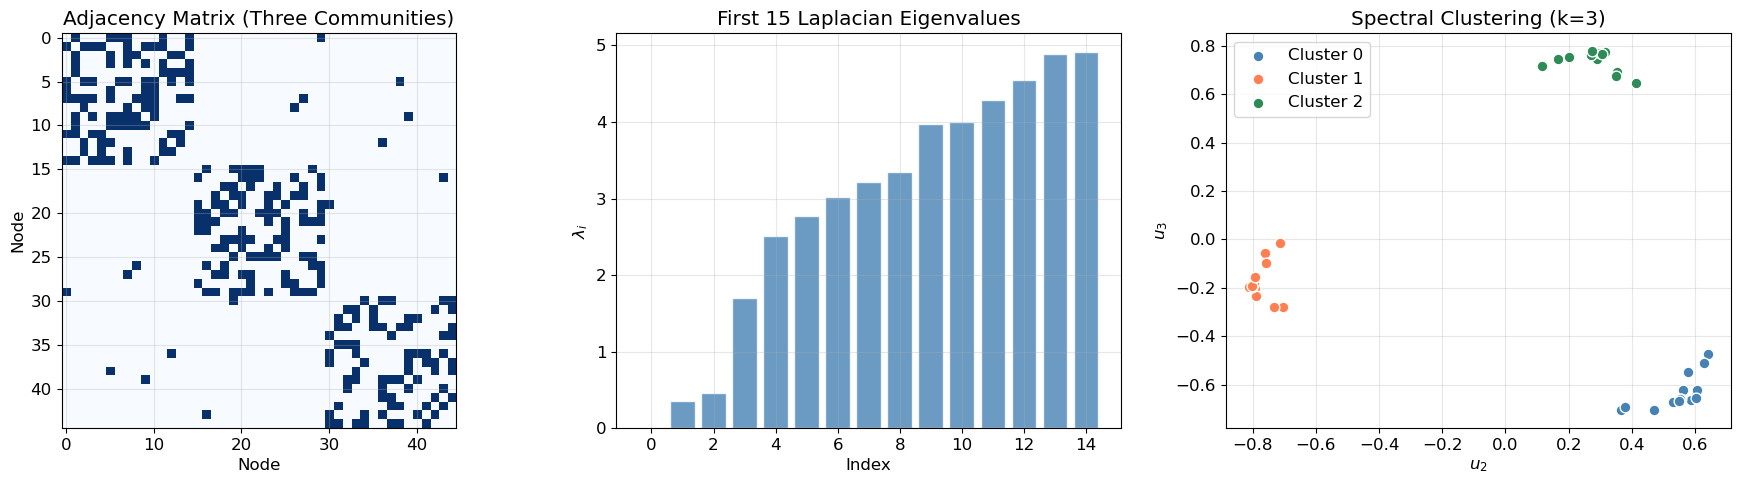

In [24]:
# =============================================================================
# 9.4 Spectral clustering on a larger example (3 communities)
# =============================================================================

np.random.seed(SEED)

# Three-community graph
n_per = 15
n_3 = 3 * n_per
edges_3 = []

for c in range(3):
    offset = c * n_per
    for i in range(offset, offset + n_per):
        for j in range(i + 1, offset + n_per):
            if np.random.rand() < 0.4:
                edges_3.append((i, j))

# Inter-community edges (sparse)
for _ in range(3):
    edges_3.append((np.random.randint(0, n_per),
                    np.random.randint(n_per, 2 * n_per)))
    edges_3.append((np.random.randint(n_per, 2 * n_per),
                    np.random.randint(2 * n_per, 3 * n_per)))
    edges_3.append((np.random.randint(0, n_per),
                    np.random.randint(2 * n_per, 3 * n_per)))

A_3 = adjacency_matrix(n_3, edges_3)
labels_3, emb_3 = spectral_cluster(A_3, k=3, use_normalized=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Adjacency matrix
axes[0].imshow(A_3, cmap='Blues', interpolation='nearest')
axes[0].set_title('Adjacency Matrix (Three Communities)')
axes[0].set_xlabel('Node')
axes[0].set_ylabel('Node')

# Eigenvalue spectrum
eigs_3 = la.eigvalsh(laplacian(A_3))
axes[1].bar(range(min(15, len(eigs_3))), eigs_3[:15], color=PRIMARY,
            alpha=0.8, edgecolor='white')
axes[1].set_title('First 15 Laplacian Eigenvalues')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('$\\lambda_i$')

# 3D spectral embedding (projected to 2D)
color_map = {0: PRIMARY, 1: SECONDARY, 2: TERTIARY}
for c in range(3):
    mask = labels_3 == c
    axes[2].scatter(emb_3[mask, 1], emb_3[mask, 2], c=color_map[c],
                    s=60, edgecolors='white', label=f'Cluster {c}', zorder=3)
axes[2].set_title('Spectral Clustering (k=3)')
axes[2].set_xlabel('$u_2$')
axes[2].set_ylabel('$u_3$')
axes[2].legend()

plt.tight_layout()
plt.show()

# =============================================================================
# Section 10 — Extensions and Advanced Topics
# =============================================================================

### 10.1 Directed Graphs and the Perron-Frobenius Theorem

For directed graphs, the adjacency matrix $A$ is no longer symmetric. The relevant
spectral theory involves:

- **Perron-Frobenius theorem**: For a non-negative irreducible matrix $A$, there
  exists a unique largest eigenvalue $\rho(A)$ (the spectral radius) with a
  positive eigenvector.
- **PageRank**: $\pi = \alpha A^\top D_{\text{out}}^{-1} \pi + (1-\alpha)\frac{1}{n}\mathbf{1}$

### 10.2 Time-Varying Graphs

In many robotics applications, the communication graph changes over time:

$$\dot{x}(t) = -L(t) \, x(t)$$

**Key result** (Moreau, 2005): Consensus is achieved if the union of communication graphs
over each bounded interval is connected.

### 10.3 Distributed Estimation on Graphs

Distributed Kalman filtering and distributed optimization use graph structure:

$$\boxed{\hat{x}_i^{+} = \hat{x}_i + \epsilon \sum_{j \in \mathcal{N}_i} (\hat{x}_j - \hat{x}_i) + K_i(y_i - H_i \hat{x}_i)}$$

The convergence of such algorithms depends on the spectral properties of $L$.

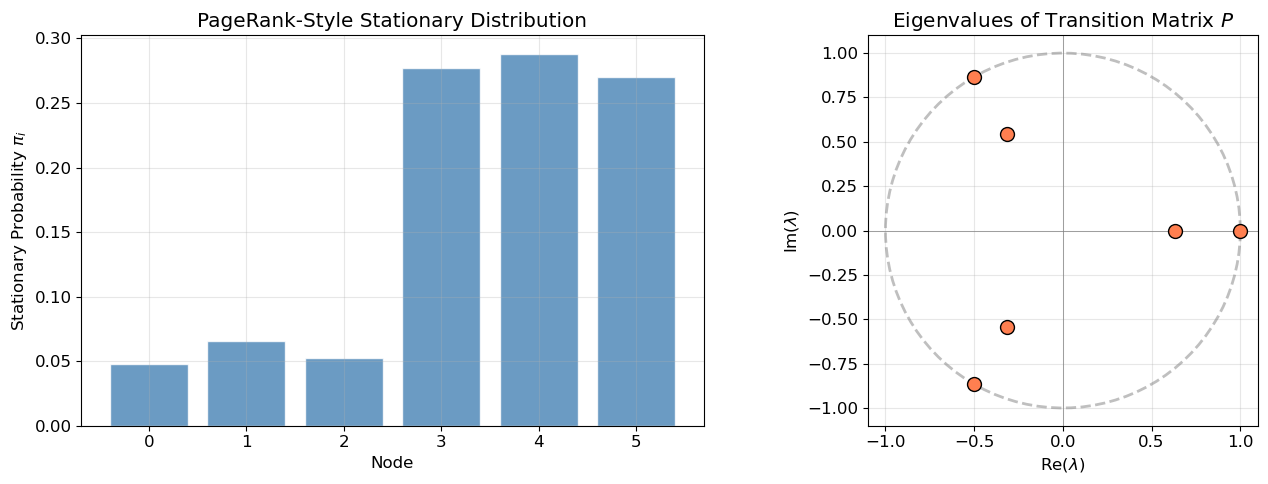

In [25]:
# =============================================================================
# 10.1 Directed graph example: PageRank-like computation
# =============================================================================

np.random.seed(SEED)

N_DIR = 6
# Directed adjacency matrix (not symmetric)
A_dir = np.zeros((N_DIR, N_DIR))
dir_edges = [(0, 1), (1, 2), (2, 0), (2, 3), (3, 4), (4, 5), (5, 3), (1, 4)]
for i, j in dir_edges:
    A_dir[i, j] = 1.0

# Out-degree matrix
D_out = np.diag(np.sum(A_dir, axis=1))
D_out_inv = np.diag(
    np.where(np.diag(D_out) > 0, 1.0 / np.diag(D_out), 0.0)
)

# Transition matrix
P = D_out_inv @ A_dir

# Power iteration for stationary distribution
pi = np.ones(N_DIR) / N_DIR
alpha = 0.85
for _ in range(200):
    pi = alpha * P.T @ pi + (1 - alpha) / N_DIR * np.ones(N_DIR)
    pi = pi / pi.sum()

# Eigenvalues of transition matrix
eigs_P = la.eigvals(P)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PageRank scores
axes[0].bar(range(N_DIR), pi, color=PRIMARY, alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Node')
axes[0].set_ylabel('Stationary Probability $\\pi_i$')
axes[0].set_title('PageRank-Style Stationary Distribution')
axes[0].set_xticks(range(N_DIR))

# Right: Eigenvalues of transition matrix in complex plane
axes[1].scatter(eigs_P.real, eigs_P.imag, c=SECONDARY, s=100,
                edgecolors='black', linewidths=1, zorder=5)
theta_circle = np.linspace(0, 2 * np.pi, 100)
axes[1].plot(np.cos(theta_circle), np.sin(theta_circle), '--',
             color='gray', alpha=0.5)
axes[1].set_xlabel('Re($\\lambda$)')
axes[1].set_ylabel('Im($\\lambda$)')
axes[1].set_title('Eigenvalues of Transition Matrix $P$')
axes[1].set_aspect('equal')
axes[1].axhline(y=0, color='gray', linewidth=0.5)
axes[1].axvline(x=0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

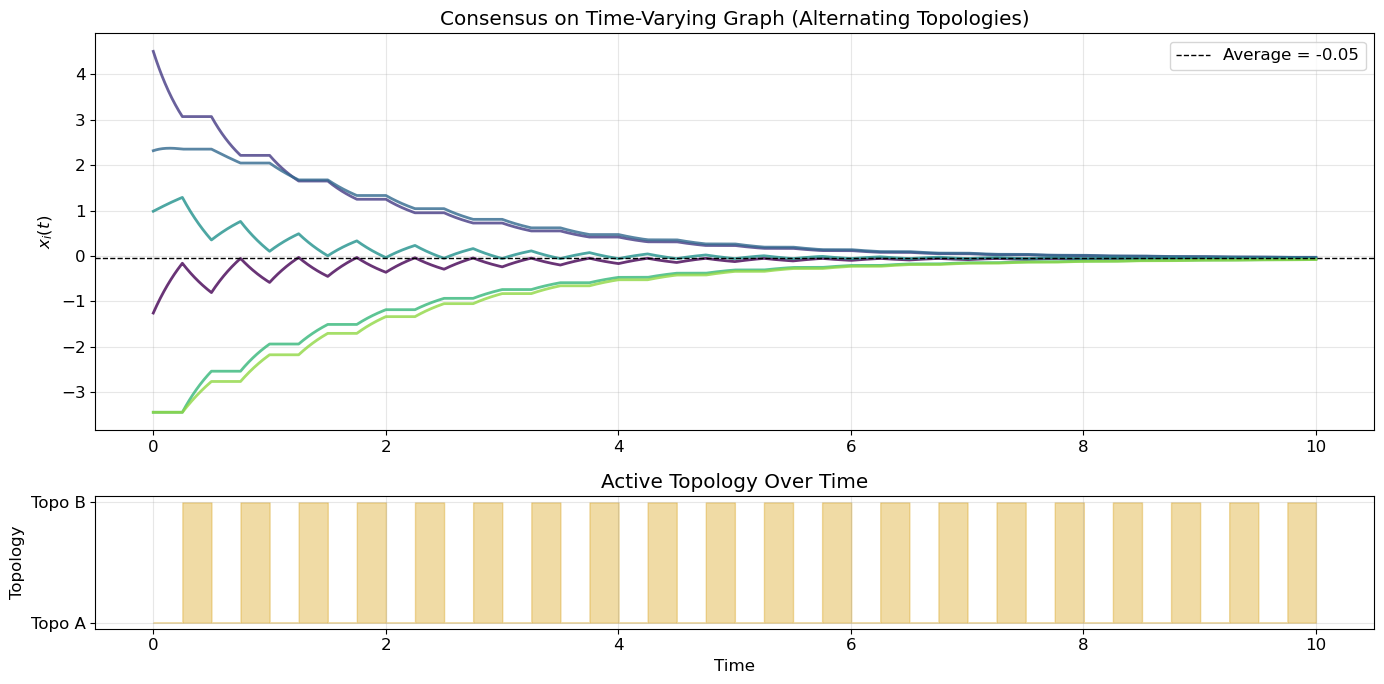


Joint connectivity ensures consensus despite individual topologies being disconnected.


In [26]:
# =============================================================================
# 10.2 Time-varying graph consensus
# =============================================================================

np.random.seed(SEED)

N_TV = 6
x0_tv = np.random.uniform(-5, 5, N_TV)
n_steps_tv = 2000
dt_tv = 0.005
t_tv = np.linspace(0, n_steps_tv * dt_tv, n_steps_tv)

# Define two alternating topologies
edges_A_tv = [(0, 1), (1, 2), (2, 3)]
edges_B_tv = [(3, 4), (4, 5), (5, 0)]

A_tv_a = adjacency_matrix(N_TV, edges_A_tv)
A_tv_b = adjacency_matrix(N_TV, edges_B_tv)
L_tv_a = laplacian(A_tv_a)
L_tv_b = laplacian(A_tv_b)

# Switch topology every 50 steps
x_tv = x0_tv.copy().astype(float)
x_hist_tv = np.zeros((n_steps_tv, N_TV))
topo_hist = np.zeros(n_steps_tv)

switch_period = 50
for step in range(n_steps_tv):
    x_hist_tv[step] = x_tv.copy()
    if (step // switch_period) % 2 == 0:
        L_current = L_tv_a
        topo_hist[step] = 0
    else:
        L_current = L_tv_b
        topo_hist[step] = 1
    x_tv = x_tv - dt_tv * L_current @ x_tv

fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                         gridspec_kw={'height_ratios': [3, 1]})

cmap = plt.cm.get_cmap(CMAP_EVOLUTION)
for i in range(N_TV):
    axes[0].plot(t_tv, x_hist_tv[:, i], color=cmap(i / N_TV), alpha=0.8)
axes[0].axhline(y=np.mean(x0_tv), color='black', linestyle='--', linewidth=1,
                label=f'Average = {np.mean(x0_tv):.2f}')
axes[0].set_ylabel('$x_i(t)$')
axes[0].set_title('Consensus on Time-Varying Graph (Alternating Topologies)')
axes[0].legend()

# Topology indicator
axes[1].fill_between(t_tv, topo_hist, step='post', alpha=0.4, color=ACCENT)
axes[1].set_ylabel('Topology')
axes[1].set_xlabel('Time')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Topo A', 'Topo B'])
axes[1].set_title('Active Topology Over Time')

plt.tight_layout()
plt.show()

print("\nJoint connectivity ensures consensus despite individual "
      "topologies being disconnected.")

In [27]:
# =============================================================================
# Summary of Key Results
# =============================================================================

print("=" * 70)
print("SPECTRAL GRAPH THEORY - KEY RESULTS SUMMARY")
print("=" * 70)
print()
print("1. Graph Laplacian: L = D - A = B B^T")
print("   - Symmetric, PSD, nullity = number of connected components")
print()
print("2. Algebraic Connectivity: lambda_2 > 0 iff graph is connected")
print("   - Fiedler vector gives optimal graph bisection")
print()
print("3. Cheeger Inequality: lambda_2/2 <= h(G) <= sqrt(2*lambda_2)")
print("   - Bridges spectral and combinatorial graph properties")
print()
print("4. Spectral Clustering: embed nodes via eigenvectors of L")
print("   - k-way partitioning using first k eigenvectors")
print()
print("5. Consensus: dx/dt = -Lx converges at rate lambda_2")
print("   - Multi-robot rendezvous, formation control")
print()
print("6. Rigidity: rank(R) = d*n - d*(d+1)/2 for rigid frameworks")
print("   - Laman's theorem: m >= 2n-3 (necessary in 2D)")
print()
print("=" * 70)

SPECTRAL GRAPH THEORY - KEY RESULTS SUMMARY

1. Graph Laplacian: L = D - A = B B^T
   - Symmetric, PSD, nullity = number of connected components

2. Algebraic Connectivity: lambda_2 > 0 iff graph is connected
   - Fiedler vector gives optimal graph bisection

3. Cheeger Inequality: lambda_2/2 <= h(G) <= sqrt(2*lambda_2)
   - Bridges spectral and combinatorial graph properties

4. Spectral Clustering: embed nodes via eigenvectors of L
   - k-way partitioning using first k eigenvectors

5. Consensus: dx/dt = -Lx converges at rate lambda_2
   - Multi-robot rendezvous, formation control

6. Rigidity: rank(R) = d*n - d*(d+1)/2 for rigid frameworks
   - Laman's theorem: m >= 2n-3 (necessary in 2D)

